To help make some useful figures, pulling in saved data

In [2]:
# --- Cell 1: Load the cleaned CONUS modelling dataset ---

import pandas as pd

data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"

event_df = pd.read_parquet(data_path)

event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)
event_df["storm"] = event_df["storm"].astype(str)

if "t90" not in event_df.columns and "t90_lastcross" in event_df.columns:
    event_df["t90"] = event_df["t90_lastcross"]

print("Loaded cleaned CONUS modelling dataset")
print("Shape:", event_df.shape)
print("Columns:", event_df.columns.tolist())
print()
print(event_df.head().to_string(index=False))

Loaded cleaned CONUS modelling dataset
Shape: (913, 42)
Columns: ['event_id', 'storm', 'CountyFIPS', 'county', 'event_start', 'duration_hours', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'n_periods', 'integral', 'pop_hours_supply_lost', 'duration_days', 'year', 'month', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'weather_hours_available', 'weather_hours_used', 'matched_ibtracs_storm', 'min_dist_to_storm_km', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita', 'storm_max_wind_center_in_conus_mps', 'storm_max_wind_near_conus_mps', 't90_lastcross', 'censored_lastcross', 'crossing_time_lastcross', 't50', 't50_censored', 'peak_outage_clean_t50', 'threshold_used_t50', 'crossing_time_t50', 'max_outage_raw', 'hours_above_thresh_raw', 'n_ts_points', 'is_valid', 't90', 't90_censored', 'peak_outage_clean']

                 event_id         storm CountyFIPS       county         event_start  duration_hours  county_pop  pre_outage_tr

This histogram shows the distribution of t90 across the cleaned CONUS modelling dataset.
It is useful for checking the overall recovery-time spread and whether the target has a long tail.


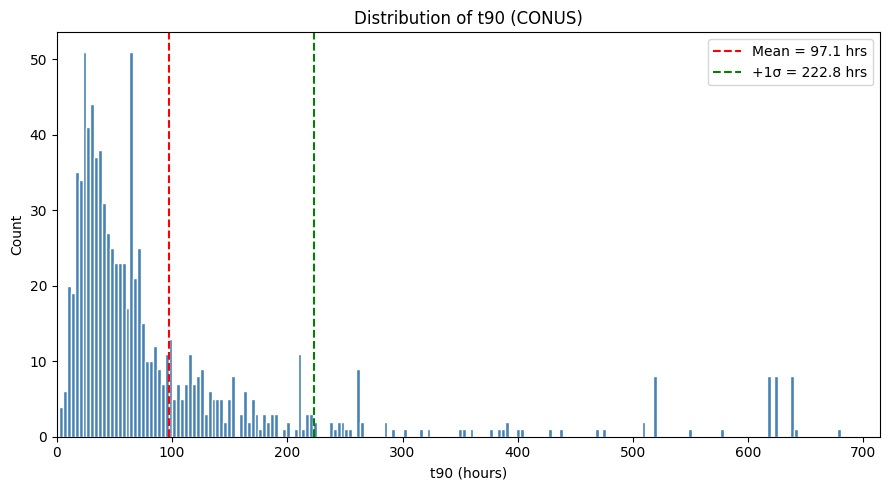


Interpretation note:
If this is strongly right-skewed, that means a small number of long recovery events are stretching the tail.
That is relevant for model choice, because tree-based models usually handle this kind of distribution better than a linear model.


In [8]:
# --- Cell 2: Histogram of t90 ---

import matplotlib.pyplot as plt
import numpy as np

if "t90" not in event_df.columns:
    raise RuntimeError("t90 is missing from event_df.")

t90_vals = event_df["t90"].dropna().astype(float)

print(
    "This histogram shows the distribution of t90 across the cleaned CONUS modelling dataset.\n"
    "It is useful for checking the overall recovery-time spread and whether the target has a long tail."
)

mean_t90 = t90_vals.mean()
std_t90 = t90_vals.std(ddof=0)
upper_1sd = mean_t90 + std_t90
lower_1sd = mean_t90 - std_t90

plt.figure(figsize=(9, 5))
plt.hist(t90_vals, bins=200, color="steelblue", edgecolor="white")

plt.axvline(mean_t90, color="red", linestyle="--", linewidth=1.5, label=f"Mean = {mean_t90:.1f} hrs")

if lower_1sd > 0:
    plt.axvline(lower_1sd, color="green", linestyle="--", linewidth=1.5, label=f"-1σ = {lower_1sd:.1f} hrs")

plt.axvline(upper_1sd, color="green", linestyle="--", linewidth=1.5, label=f"+1σ = {upper_1sd:.1f} hrs")

plt.xlabel("t90 (hours)")
plt.ylabel("Count")
plt.title("Distribution of t90 (CONUS)")
plt.xlim(left=0)
plt.legend()
plt.tight_layout()
plt.show()

print(
    "\nInterpretation note:\n"
    "If this is strongly right-skewed, that means a small number of long recovery events are stretching the tail.\n"
    "That is relevant for model choice, because tree-based models usually handle this kind of distribution better than a linear model."
)

This map shows how many county-event observations are present in the cleaned CONUS modelling dataset.
It is a frequency map, not a severity map: counties with more event rows are darker.


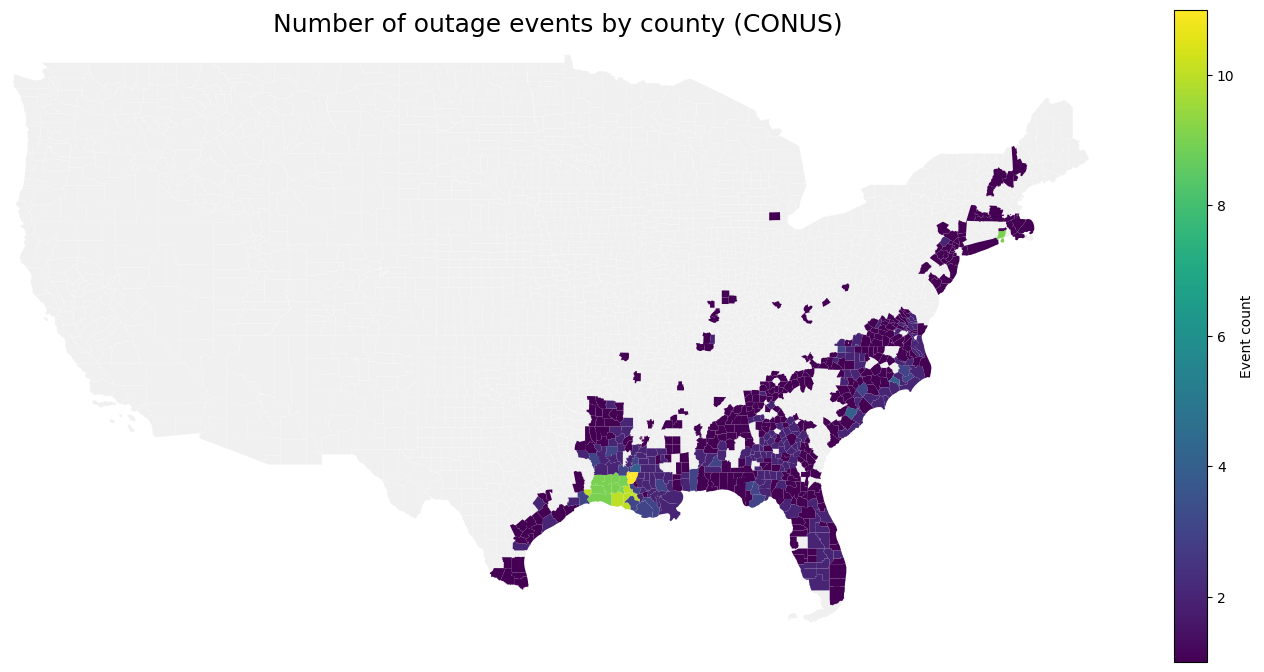


Interpretation note:
This is counting county-event rows, not unique storms.
A county can appear more than once if it is affected by multiple named storms or multiple event windows.


In [11]:
# --- Cell 3: County map showing number of outage events ---

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

print(
    "This map shows how many county-event observations are present in the cleaned CONUS modelling dataset.\n"
    "It is a frequency map, not a severity map: counties with more event rows are darker."
)

county_counts = (
    event_df.groupby("CountyFIPS")
    .size()
    .reset_index(name="event_count")
)

# County geometries from Census TIGER/Line
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip"
)

counties["CountyFIPS"] = (counties["STATEFP"] + counties["COUNTYFP"]).astype(str).str.zfill(5)

# Keep lower 48 + DC only
exclude_state_fips = {"02", "15", "60", "66", "69", "72", "78"}
counties = counties[~counties["STATEFP"].isin(exclude_state_fips)].copy()

# Merge counts
counties = counties.merge(county_counts, on="CountyFIPS", how="left")
counties["event_count"] = counties["event_count"].fillna(0)

plot_df = counties[counties["event_count"] > 0].copy()
no_event_df = counties[counties["event_count"] == 0].copy()

fig, ax = plt.subplots(figsize=(14, 9))

# Background counties
if len(no_event_df) > 0:
    no_event_df.plot(
        ax=ax,
        color="#f0f0f0",
        edgecolor="white",
        linewidth=0.1
    )

# Counties with events
if len(plot_df) > 0:
    plot_df.plot(
        ax=ax,
        column="event_count",
        cmap="viridis",
        vmin=1,
        vmax=max(1, plot_df["event_count"].max()),
        legend=True,
        edgecolor="none",
        legend_kwds={"label": "Event count", "shrink": 0.75}
    )

# Crop to CONUS so Alaska/Hawaii are not shown
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title("Number of outage events by county (CONUS)", fontsize=18)
ax.set_axis_off()

plt.tight_layout()
plt.show()

print(
    "\nInterpretation note:\n"
    "This is counting county-event rows, not unique storms.\n"
    "A county can appear more than once if it is affected by multiple named storms or multiple event windows."
)

In [10]:
# --- Cell 4: Event counts by state, descending order ---

import pandas as pd
import geopandas as gpd

print(
    "This table counts county-event rows by state, in descending order.\n"
    "It is useful for checking how spatially concentrated the dataset is."
)

# County-level event counts with state FIPS
state_counts = (
    event_df.copy()
    .assign(CountyFIPS=lambda d: d["CountyFIPS"].astype(str).str.zfill(5))
    .assign(STATEFP=lambda d: d["CountyFIPS"].str[:2])
    .groupby("STATEFP")
    .size()
    .reset_index(name="event_count")
)

# State names from Census TIGER/Line
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2020/STATE/tl_2020_us_state.zip"
)

states = states[["STATEFP", "NAME", "STUSPS"]].copy()

state_counts = state_counts.merge(states, on="STATEFP", how="left")
state_counts = state_counts.sort_values("event_count", ascending=False).reset_index(drop=True)

print(state_counts[["NAME", "STUSPS", "event_count"]].to_string(index=False))

print()
print("Top 10 states by event count:")
print(state_counts[["NAME", "STUSPS", "event_count"]].head(10).to_string(index=False))

This table counts county-event rows by state, in descending order.
It is useful for checking how spatially concentrated the dataset is.
          NAME STUSPS  event_count
     Louisiana     LA          222
       Georgia     GA          161
North Carolina     NC          109
       Florida     FL           90
      Virginia     VA           70
   Mississippi     MS           53
       Alabama     AL           48
         Texas     TX           45
South Carolina     SC           29
    New Jersey     NJ           18
      Arkansas     AR           17
  Rhode Island     RI           10
 Massachusetts     MA            9
      New York     NY            9
      Kentucky     KY            5
       Indiana     IN            5
 West Virginia     WV            4
 New Hampshire     NH            3
  Pennsylvania     PA            2
     Tennessee     TN            2
         Maine     ME            1
      Michigan     MI            1

Top 10 states by event count:
          NAME STUSPS  event

correlation matrix:

Correlation matrix uses these variables:
max_gust, mean_gust_7d, total_precip_7d, pressure_min_7d, county_pop, min_dist_to_storm_km, storm_max_wind_near_conus_mps, county_gdp_real_2017_dollars, county_gdp_real_2017_per_capita, t90, t50, peak_outage_clean

Only the lower triangle is shown; the diagonal and upper triangle are masked.


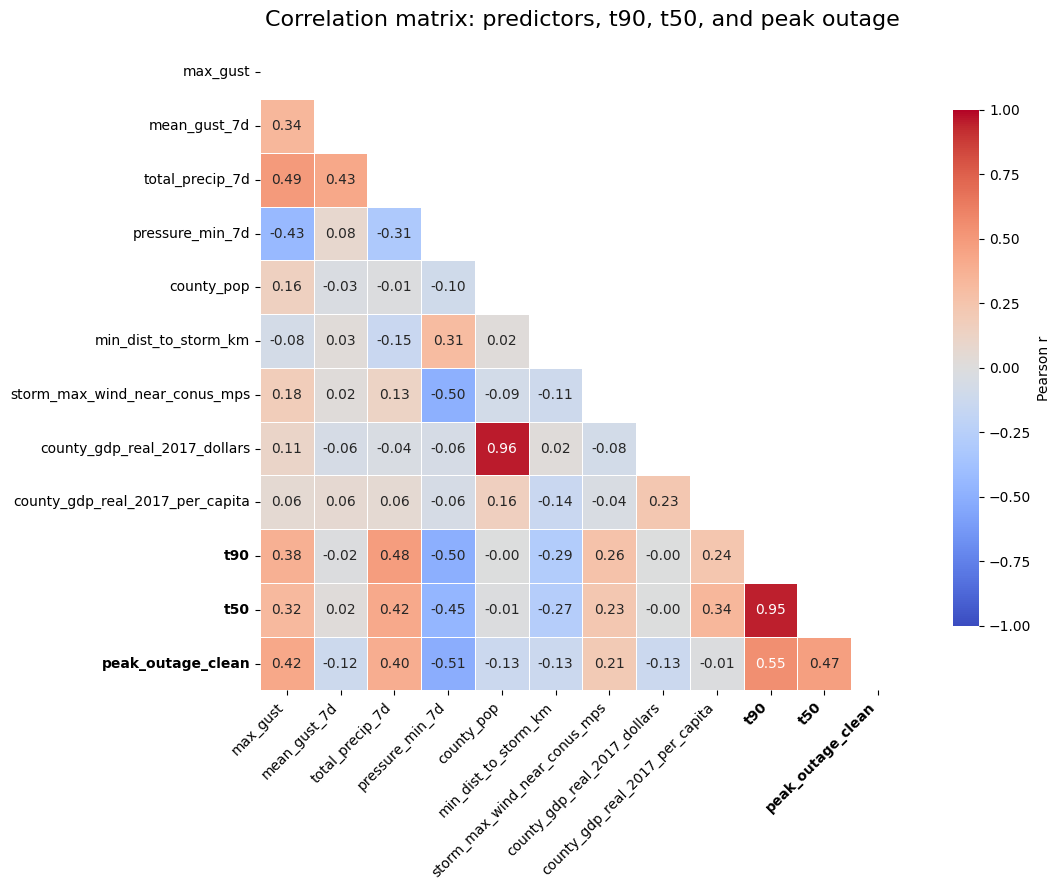

In [13]:
# --- Correlation matrix: final CONUS modelling set + targets ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"

# Load cleaned CONUS modelling dataset if it is not already in memory
df = event_df.copy() if "event_df" in globals() else pd.read_parquet(data_path)

if "CountyFIPS" in df.columns:
    df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
if "storm" in df.columns:
    df["storm"] = df["storm"].astype(str)

def resolve_col(frame, candidates, label):
    for c in candidates:
        if c in frame.columns:
            return c
    raise KeyError(f"Could not find {label}. Tried: {candidates}")

# Final 9 predictors
predictor_map = {
    "max_gust": ["max_gust"],
    "mean_gust_7d": ["mean_gust_7d"],
    "total_precip_7d": ["total_precip_7d"],
    "pressure_min_7d": ["pressure_min_7d"],
    "county_pop": ["county_pop"],
    "min_dist_to_storm_km": ["min_dist_to_storm_km"],
    "storm_max_wind_near_conus_mps": ["storm_max_wind_near_conus_mps"],
    "county_gdp_real_2017_dollars": ["county_gdp_real_2017_dollars"],
    "county_gdp_real_2017_per_capita": ["county_gdp_real_2017_per_capita"],
}

# Targets / target-like variables
target_map = {
    "t90": ["t90", "t90_lastcross"],
    "t50": ["t50", "t50_lastcross"],
    "peak_outage_clean": ["peak_outage_clean", "peak_outage_clean_t50", "max_outage_raw"],
}

cols_in_order = []
for pretty_name, candidates in {**predictor_map, **target_map}.items():
    cols_in_order.append(resolve_col(df, candidates, pretty_name))

corr_df = df[cols_in_order].apply(pd.to_numeric, errors="coerce")
corr = corr_df.corr()

# Mask diagonal + upper triangle, leaving only the lower triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

print("Correlation matrix uses these variables:")
print(", ".join(cols_in_order))
print("\nOnly the lower triangle is shown; the diagonal and upper triangle are masked.")

plt.figure(figsize=(12, 9))
ax = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)

ax.set_title("Correlation matrix: predictors, t90, t50, and peak outage", fontsize=16, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# Bold the target / target-like labels
target_labels = {"t90", "t50", "peak_outage_clean"}
for label in ax.get_xticklabels():
    if label.get_text() in target_labels:
        label.set_fontweight("bold")
for label in ax.get_yticklabels():
    if label.get_text() in target_labels:
        label.set_fontweight("bold")

plt.tight_layout()
plt.show()

Trying to emulate risk map from student NOAA paper

Selected storm: 2018280N18273
Implicated counties: 152
count    152.000000
mean      84.096747
std       94.912895
min        3.954737
25%       32.518639
50%       51.359846
75%       96.381310
max      551.473029


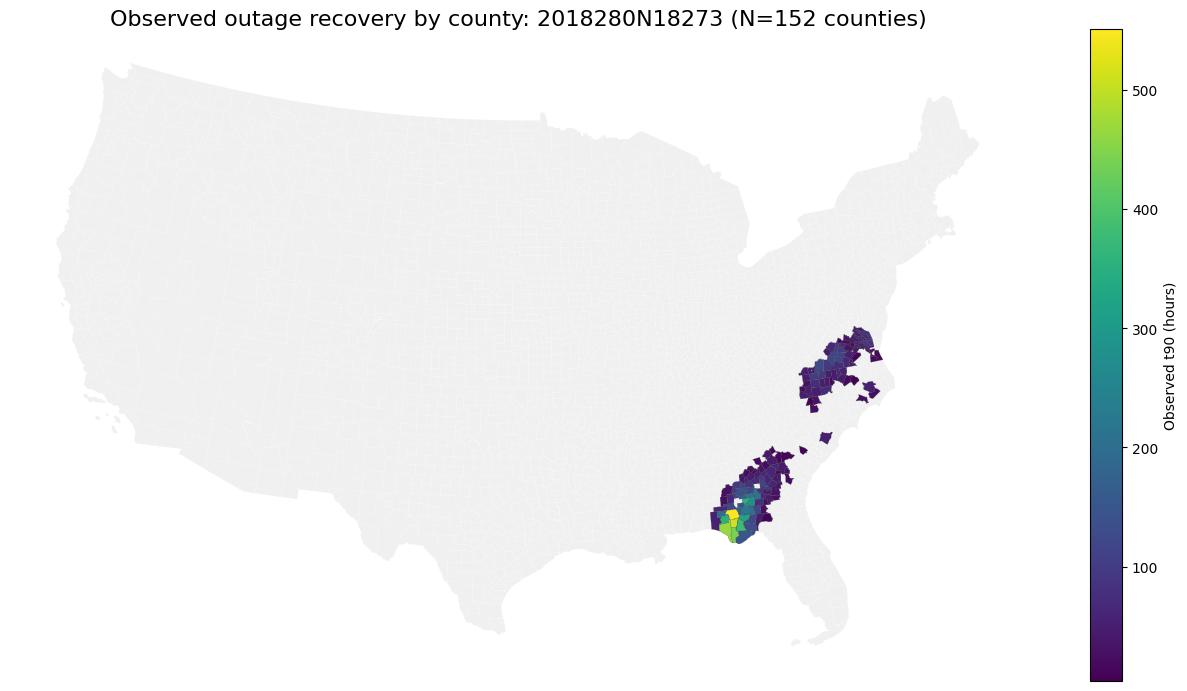

In [14]:
# --- Observed storm map: county-level t90 for the storm with the most counties ---

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Load the cleaned modelling table
data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"
df = event_df.copy() if "event_df" in globals() else pd.read_parquet(data_path)

df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
df["storm"] = df["storm"].astype(str)

if "t90" not in df.columns and "t90_lastcross" in df.columns:
    df["t90"] = df["t90_lastcross"]

if "t90" not in df.columns:
    raise RuntimeError("Could not find t90 in the dataset.")

# Pick the storm with the most implicated counties
storm_counts = df.groupby("storm")["CountyFIPS"].nunique().sort_values(ascending=False)
storm_id = storm_counts.index[0]

storm_df = df[df["storm"] == storm_id].copy()

if "event_start" in storm_df.columns:
    storm_df["event_start"] = pd.to_datetime(storm_df["event_start"], errors="coerce")
    storm_df = storm_df.sort_values("event_start")

# One value per county for this storm
storm_df = storm_df.dropna(subset=["t90"])
storm_df = storm_df.drop_duplicates(subset=["CountyFIPS"], keep="first")[["CountyFIPS", "t90"]]

print(f"Selected storm: {storm_id}")
print(f"Implicated counties: {len(storm_df)}")
print(storm_df["t90"].describe().to_string())

# County geometries
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip"
)

counties["CountyFIPS"] = (counties["STATEFP"] + counties["COUNTYFP"]).astype(str).str.zfill(5)

# Keep lower 48 + DC only
exclude_state_fips = {"02", "15", "60", "66", "69", "72", "78"}
counties = counties[~counties["STATEFP"].isin(exclude_state_fips)].copy()

# Project for a cleaner map
counties = counties.to_crs(epsg=5070)

# Merge observed t90 onto counties
counties = counties.merge(storm_df, on="CountyFIPS", how="left")

# Plot
fig, ax = plt.subplots(figsize=(13, 9))

# Background counties
counties[counties["t90"].isna()].plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="white",
    linewidth=0.08
)

# Storm counties
storm_only = counties[counties["t90"].notna()].copy()
storm_only.plot(
    ax=ax,
    column="t90",
    cmap="viridis",
    edgecolor="#333333",
    linewidth=0.15,
    legend=True,
    norm=Normalize(vmin=storm_only["t90"].min(), vmax=storm_only["t90"].max()),
    legend_kwds={"label": "Observed t90 (hours)", "shrink": 0.75}
)

ax.set_title(f"Observed outage recovery by county: {storm_id} (N={len(storm_df)} counties)", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

need to import xgb results:

In [ ]:
import json
from pathlib import Path

with open(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\best_model_params_conus.json") as f:
    model_params = json.load(f)

rf_best_params = model_params["rf_best_params"]
xgb_best_params = model_params["xgb_best_params"]

In [15]:
# --- Predicted storm map: county-level t90 for the storm with the most counties ---

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# Load cleaned modelling table
data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"
df = event_df.copy() if "event_df" in globals() else pd.read_parquet(data_path)

df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
df["storm"] = df["storm"].astype(str)

if "t90" not in df.columns and "t90_lastcross" in df.columns:
    df["t90"] = df["t90_lastcross"]

if "best_candidate_3" not in globals():
    raise RuntimeError("best_candidate_3 is missing. Run the XGB tuning cell first.")

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

# Fit the tuned XGB model on the full cleaned CONUS modelling dataset
xgb_params = {
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
    "learning_rate": float(best_candidate_3["learning_rate"]),
    "n_estimators": int(best_candidate_3["n_estimators"]),
    "max_depth": int(best_candidate_3["max_depth"]),
    "min_child_weight": int(best_candidate_3["min_child_weight"]),
    "subsample": float(best_candidate_3["subsample"]),
    "colsample_bytree": float(best_candidate_3["colsample_bytree"]),
    "gamma": float(best_candidate_3["gamma"]),
    "reg_alpha": float(best_candidate_3["reg_alpha"]),
    "reg_lambda": float(best_candidate_3["reg_lambda"]),
}

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

model = Pipeline([
    ("preprocess", preprocess),
    ("xgb", XGBRegressor(**xgb_params)),
])

model.fit(df[features_v4], df["t90"])

# Pick the storm with the most implicated counties
storm_counts = df.groupby("storm")["CountyFIPS"].nunique().sort_values(ascending=False)
storm_id = storm_counts.index[0]

storm_df = df[df["storm"] == storm_id].copy()

if "event_start" in storm_df.columns:
    storm_df["event_start"] = pd.to_datetime(storm_df["event_start"], errors="coerce")
    storm_df = storm_df.sort_values("event_start")

# One row per county for the map
storm_df = storm_df.drop_duplicates(subset=["CountyFIPS"], keep="first").copy()
storm_df["pred_t90"] = model.predict(storm_df[features_v4])

print(f"Selected storm: {storm_id}")
print(f"Implicated counties: {len(storm_df)}")
print(storm_df["pred_t90"].describe().to_string())

# County geometries
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip"
)

counties["CountyFIPS"] = (counties["STATEFP"] + counties["COUNTYFP"]).astype(str).str.zfill(5)

# Keep lower 48 + DC only
exclude_state_fips = {"02", "15", "60", "66", "69", "72", "78"}
counties = counties[~counties["STATEFP"].isin(exclude_state_fips)].copy()

# Project for a cleaner map
counties = counties.to_crs(epsg=5070)

# Merge predicted values onto counties
counties = counties.merge(storm_df[["CountyFIPS", "pred_t90"]], on="CountyFIPS", how="left")

fig, ax = plt.subplots(figsize=(13, 9))

# Background counties
counties[counties["pred_t90"].isna()].plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="white",
    linewidth=0.08
)

# Storm counties
storm_only = counties[counties["pred_t90"].notna()].copy()
storm_only.plot(
    ax=ax,
    column="pred_t90",
    cmap="viridis",
    edgecolor="#333333",
    linewidth=0.15,
    legend=True,
    legend_kwds={"label": "Predicted t90 (hours)", "shrink": 0.75}
)

ax.set_title(
    f"Predicted outage recovery by county: {storm_id} (N={len(storm_df)} counties)",
    fontsize=16
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(
    "\nInterpretation note:\n"
    "This is an in-sample illustration, because the model is trained on the full cleaned CONUS dataset.\n"
    "It is useful for seeing the spatial pattern of predicted recovery times within one storm, not for assessing generalisation."
)

RuntimeError: best_candidate_3 is missing. Run the XGB tuning cell first.

Trying active learning / hard-mining example / adaptive sampling:

In [2]:
# --- Diagnostic summary for storm-based adaptive sampling ---

import pandas as pd
import numpy as np

# Load cleaned modelling table
data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"
df = event_df.copy() if "event_df" in globals() else pd.read_parquet(data_path)

df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
df["storm"] = df["storm"].astype(str)

if "t90" not in df.columns and "t90_lastcross" in df.columns:
    df["t90"] = df["t90_lastcross"]

if "t90" not in df.columns:
    raise RuntimeError("Could not find t90 in the dataset.")

# Basic counts
n_rows = len(df)
n_storms = df["storm"].nunique(dropna=True)
n_counties = df["CountyFIPS"].nunique(dropna=True)
n_pairs = df[["storm", "CountyFIPS"]].drop_duplicates().shape[0]

print("Dataset summary")
print("----------------")
print(f"County-event rows: {n_rows}")
print(f"Unique storms:     {n_storms}")
print(f"Unique counties:   {n_counties}")
print(f"Unique storm × county pairs: {n_pairs}")

# Storm-level concentration
storm_sizes = df.groupby("storm").size().sort_values(ascending=False)
storm_county_sizes = df.groupby("storm")["CountyFIPS"].nunique().sort_values(ascending=False)

print()
print("Events per storm")
print("----------------")
print(storm_sizes.describe().to_string())

print()
print("Unique counties per storm")
print("-------------------------")
print(storm_county_sizes.describe().to_string())

# How concentrated is the dataset?
storm_cumshare = storm_sizes.cumsum() / storm_sizes.sum()
storms_for_50 = int((storm_cumshare < 0.5).sum() + 1)
storms_for_80 = int((storm_cumshare < 0.8).sum() + 1)

print()
print("Concentration")
print("-------------")
print(f"Storms needed for 50% of all county-event rows: {storms_for_50}")
print(f"Storms needed for 80% of all county-event rows: {storms_for_80}")

print()
print("Top 10 storms by number of county-event rows")
print("-------------------------------------------")
print(storm_sizes.head(10).to_string())

print()
print("Top 10 storms by number of unique counties")
print("------------------------------------------")
print(storm_county_sizes.head(10).to_string())

# Helpful note for deciding whether a fixed curriculum is sensible
print()
print("Interpretation")
print("--------------")
print(
    "If a small number of storms account for a large share of rows, a storm-level curriculum may be informative.\n"
    "If counts are fairly even, adaptive ordering is less likely to help much beyond random ordering."
)

Dataset summary
----------------
County-event rows: 913
Unique storms:     28
Unique counties:   560
Unique storm × county pairs: 817

Events per storm
----------------
count     28.000000
mean      32.607143
std       41.416886
min        1.000000
25%        4.000000
50%       12.500000
75%       42.250000
max      152.000000

Unique counties per storm
-------------------------
count     28.000000
mean      29.178571
std       39.185271
min        1.000000
25%        4.000000
50%       12.000000
75%       39.250000
max      152.000000

Concentration
-------------
Storms needed for 50% of all county-event rows: 4
Storms needed for 80% of all county-event rows: 9

Top 10 storms by number of county-event rows
-------------------------------------------
storm
2018280N18273    152
2017242N16333    127
2020233N14313    104
2020299N18277     96
2020211N13306     68
2020234N14280     60
2020279N16284     49
2018242N13343     40
2021239N17281     39
2022263N10313     34

Top 10 storms by numbe

It does a storm-level, training-only hard-first curriculum versus random storm ordering, with t90 modelled on the log scale and converted back to hours for MAE:

Storm curriculum dataset summary
--------------------------------
County-event rows: 913
Unique storms:     28
Unique counties:   560

Adaptive-sampling summary
-------------------------
  strategy  sample_fraction  mae_mean    mae_sd  n_train_storms_used_mean  n_train_rows_used_mean  n_test_rows_mean
Hard-first              0.1 47.675682 19.208314                       3.0                  154.20             182.6
Hard-first              0.2 45.775235 19.153899                       5.0                  319.40             182.6
Hard-first              0.3 41.011316 16.767592                       7.2                  436.80             182.6
Hard-first              0.4 39.706537 17.809893                       9.4                  524.80             182.6
Hard-first              0.5 38.980548 16.927115                      11.4                  544.00             182.6
Hard-first              0.6 39.084568 15.778372                      14.0                  562.00             182.6
H

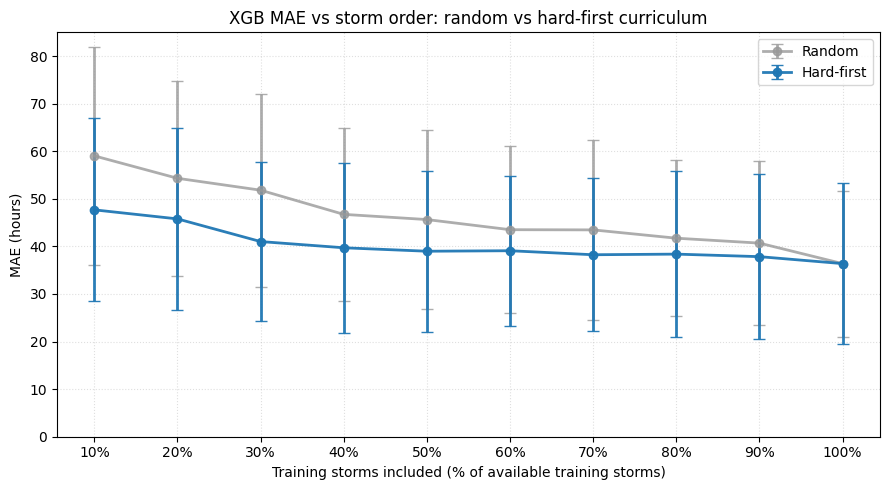

In [3]:
# --- Storm-level curriculum / hard-first ordering vs random ordering ---
# Uses a training-only hardness ranking to avoid leakage.
# Target is modelled on log1p(t90) and transformed back to hours for MAE.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor

# -----------------------
# Load data
# -----------------------
data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"
df = event_df.copy() if "event_df" in globals() else pd.read_parquet(data_path)

df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
df["storm"] = df["storm"].astype(str)

if "t90" not in df.columns and "t90_lastcross" in df.columns:
    df["t90"] = df["t90_lastcross"]

if "t90" not in df.columns:
    raise RuntimeError("Could not find t90 in the dataset.")

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

print("Storm curriculum dataset summary")
print("--------------------------------")
print(f"County-event rows: {len(df)}")
print(f"Unique storms:     {df['storm'].nunique(dropna=True)}")
print(f"Unique counties:   {df['CountyFIPS'].nunique(dropna=True)}")

# -----------------------
# Tuned XGB hyperparameters
# -----------------------
xgb_params = {
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
    "learning_rate": 0.3,
    "n_estimators": 100,
    "max_depth": 6,
    "min_child_weight": 1,
    "subsample": 1.0,
    "colsample_bytree": 0.7,
    "gamma": 0.5,
    "reg_alpha": 0.0,
    "reg_lambda": 8.0,
}

# -----------------------
# Helpers
# -----------------------
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

def make_log_mlr():
    base = Pipeline([
        ("preprocess", preprocess),
        ("lr", LinearRegression()),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )

def make_log_xgb():
    base = Pipeline([
        ("preprocess", preprocess),
        ("xgb", XGBRegressor(**xgb_params)),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )

def clip_nonnegative(arr):
    return np.clip(np.asarray(arr, dtype=float), 0.0, None)

def fit_predict_mae(train_df, test_df, model_factory):
    X_train = train_df[features_v4].copy()
    y_train = train_df["t90"].astype(float).copy()
    X_test = test_df[features_v4].copy()
    y_test = test_df["t90"].astype(float).copy()

    model = model_factory()
    model.fit(X_train, y_train)
    preds = clip_nonnegative(model.predict(X_test))
    mae = mean_absolute_error(y_test, preds)
    return mae

def rank_training_storms_by_hardness(train_df):
    """
    Training-only storm ranking:
    - leave one storm out within the training split
    - fit a simple log-linear baseline
    - score each left-out storm by MAE in hours
    - rank storms from hardest to easiest
    """
    storms = list(train_df["storm"].dropna().unique())
    if len(storms) < 2:
        return storms

    scores = []
    for storm in storms:
        inner_train = train_df[train_df["storm"] != storm].copy()
        inner_test = train_df[train_df["storm"] == storm].copy()

        if len(inner_test) == 0 or len(inner_train) == 0:
            continue

        mae = fit_predict_mae(inner_train, inner_test, make_log_mlr)
        scores.append((storm, mae))

    if not scores:
        return storms

    # Hardest first
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    return [s for s, _ in scores]

def evaluate_order_curve(train_df, test_df, storm_order, fractions, model_factory):
    """
    Train on prefixes of storm_order and evaluate on the held-out test_df.
    Returns one row per fraction.
    """
    rows = []
    n_train_storms = len(storm_order)

    for frac in fractions:
        n_keep = int(np.ceil(frac * n_train_storms))
        n_keep = max(2, min(n_keep, n_train_storms))
        selected_storms = storm_order[:n_keep]

        subset = train_df[train_df["storm"].isin(selected_storms)].copy()
        if subset["storm"].nunique() < 2 or len(subset) == 0:
            continue

        mae = fit_predict_mae(subset, test_df, model_factory)
        rows.append({
            "sample_fraction": frac,
            "n_train_storms_total": n_train_storms,
            "n_train_storms_used": subset["storm"].nunique(),
            "n_train_rows_used": len(subset),
            "n_test_rows": len(test_df),
            "mae": mae,
        })

    return rows

# -----------------------
# Outer storm-grouped evaluation
# -----------------------
storms = df["storm"].dropna().unique()
n_storms = len(storms)

if n_storms < 3:
    raise RuntimeError("Not enough storms for grouped outer evaluation.")

n_outer_splits = min(5, n_storms)
outer_cv = GroupKFold(n_splits=n_outer_splits)
fractions = np.arange(0.1, 1.01, 0.1)
n_random_orders_per_fold = 10

curve_rows = []
rng = np.random.default_rng(42)

for outer_fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(df, df["t90"], groups=df["storm"]),
    start=1
):
    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    train_df["storm"] = train_df["storm"].astype(str)
    test_df["storm"] = test_df["storm"].astype(str)

    train_storms = list(train_df["storm"].dropna().unique())
    if len(train_storms) < 2:
        continue

    # Hard-first ordering learned only from the outer training data
    hard_order = rank_training_storms_by_hardness(train_df)
    hard_rows = evaluate_order_curve(
        train_df=train_df,
        test_df=test_df,
        storm_order=hard_order,
        fractions=fractions,
        model_factory=make_log_xgb,
    )
    for r in hard_rows:
        r["strategy"] = "Hard-first"
        r["outer_fold"] = outer_fold
        curve_rows.append(r)

    # Random orders baseline
    for rep in range(1, n_random_orders_per_fold + 1):
        random_order = list(rng.permutation(train_storms))
        rand_rows = evaluate_order_curve(
            train_df=train_df,
            test_df=test_df,
            storm_order=random_order,
            fractions=fractions,
            model_factory=make_log_xgb,
        )
        for r in rand_rows:
            r["strategy"] = "Random"
            r["outer_fold"] = outer_fold
            r["repeat"] = rep
            curve_rows.append(r)

curve_df = pd.DataFrame(curve_rows)

if curve_df.empty:
    raise RuntimeError("No curve results were produced. Check the grouped splits and training data.")

summary = (
    curve_df.groupby(["strategy", "sample_fraction"], as_index=False)
    .agg(
        mae_mean=("mae", "mean"),
        mae_sd=("mae", "std"),
        n_train_storms_used_mean=("n_train_storms_used", "mean"),
        n_train_rows_used_mean=("n_train_rows_used", "mean"),
        n_test_rows_mean=("n_test_rows", "mean"),
    )
    .sort_values(["strategy", "sample_fraction"])
    .reset_index(drop=True)
)

print("\nAdaptive-sampling summary")
print("-------------------------")
print(summary.to_string(index=False))

print("\nInterpretation note")
print("-------------------")
print(
    "Hard-first is ranked using a training-only storm hardness score from a simple log-linear baseline,\n"
    "so the held-out storms are not used to decide the order.\n"
    "MAE is reported in hours on the original scale after back-transforming the log target."
)

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(9, 5))

for strategy, color in [("Random", "0.6"), ("Hard-first", "tab:blue")]:
    sub = summary[summary["strategy"] == strategy].copy()
    x = sub["sample_fraction"] * 100
    ax.errorbar(
        x,
        sub["mae_mean"],
        yerr=sub["mae_sd"],
        marker="o",
        linewidth=2,
        capsize=4,
        label=strategy,
        color=color,
        alpha=0.95 if strategy == "Hard-first" else 0.8,
    )

ax.set_xlabel("Training storms included (% of available training storms)")
ax.set_ylabel("MAE (hours)")
ax.set_title("XGB MAE vs storm order: random vs hard-first curriculum")
ax.set_ylim(bottom=0)
ax.set_xticks(fractions * 100)
ax.set_xticklabels([f"{int(f*100)}%" for f in fractions])
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

^ not bad, but idk why the MAE doesn't go down to 32 hrs.

Here's a leaky version, not for report:

Leaky curriculum diagnostic
---------------------------
County-event rows: 913
Unique storms:     28
Unique counties:   560

Hard-first ranking derived from the full dataset (leaky by design)
------------------------------------------------------------------
        storm  baseline_mae  baseline_rmse  n_rows  n_counties
2020205N26272    168.115601     388.019099       7           7
2020234N14280    131.926517     207.305719      60          15
2021239N17281    108.372858     164.856003      39          39
2017242N16333     95.629507     173.957992     127         127
2020233N14313     95.080572     163.977358     104          59
2017228N14314     93.633416     136.292001      19          19
2018242N13343     57.219130      93.508739      40          40
2018280N18273     41.286347      84.885327     152         152
2022263N10313     31.328041      44.968890      34          34
2021256N21265     29.593351      34.061122       8           8

Leaky curriculum summary
----------------------

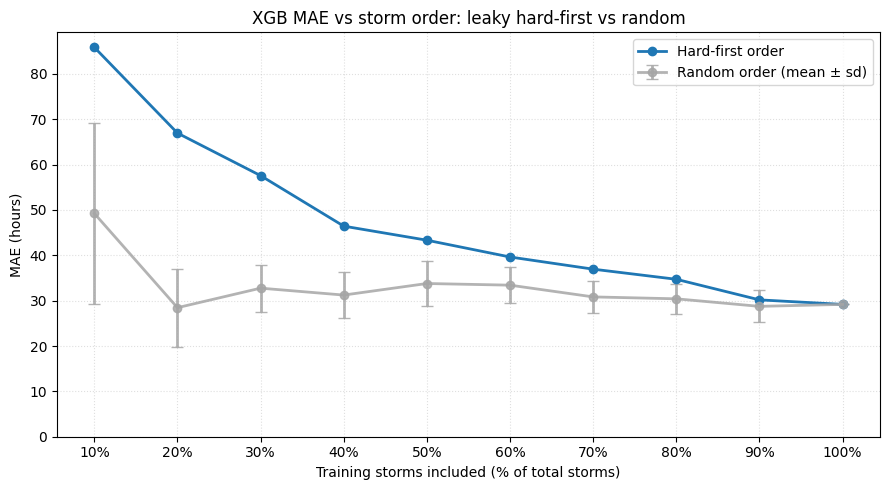

In [5]:
# --- Leaky storm curriculum curve: full-data hard-first order vs random order ---
# Intentionally leaky version for curiosity only.
# Storms are ranked once using the full dataset, then used to build cumulative subsets.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

# -----------------------
# Load data
# -----------------------
data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"
df = event_df.copy() if "event_df" in globals() else pd.read_parquet(data_path)

df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
df["storm"] = df["storm"].astype(str)

if "t90" not in df.columns and "t90_lastcross" in df.columns:
    df["t90"] = df["t90_lastcross"]

if "t90" not in df.columns:
    raise RuntimeError("Could not find t90 in the dataset.")

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

print("Leaky curriculum diagnostic")
print("---------------------------")
print(f"County-event rows: {len(df)}")
print(f"Unique storms:     {df['storm'].nunique(dropna=True)}")
print(f"Unique counties:   {df['CountyFIPS'].nunique(dropna=True)}")

# -----------------------
# Tuned XGB params from CONUS_modelling
# -----------------------
xgb_params = {
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
    "learning_rate": 0.3,
    "n_estimators": 100,
    "max_depth": 6,
    "min_child_weight": 1,
    "subsample": 1.0,
    "colsample_bytree": 0.7,
    "gamma": 0.5,
    "reg_alpha": 0.0,
    "reg_lambda": 8.0,
}

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

def make_log_mlr():
    base = Pipeline([
        ("preprocess", preprocess),
        ("lr", LinearRegression()),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )

def make_log_xgb():
    base = Pipeline([
        ("preprocess", preprocess),
        ("xgb", XGBRegressor(**xgb_params)),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )

def fit_predict_mae(train_df, test_df, model_factory):
    X_train = train_df[features_v4].copy()
    y_train = train_df["t90"].astype(float).copy()
    X_test = test_df[features_v4].copy()
    y_test = test_df["t90"].astype(float).copy()

    model = model_factory()
    model.fit(X_train, y_train)
    preds = np.asarray(model.predict(X_test), dtype=float)
    preds = np.clip(preds, 0.0, None)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return mae, rmse

def score_storm_hardness_full_data(full_df):
    """
    Leaky ranking:
    each storm is scored using the full dataset, by holding that storm out and
    fitting a simple baseline on the remaining storms.
    """
    storms = list(full_df["storm"].dropna().unique())
    scores = []

    for storm in storms:
        train_df = full_df[full_df["storm"] != storm].copy()
        test_df = full_df[full_df["storm"] == storm].copy()

        if len(train_df) == 0 or len(test_df) == 0:
            continue

        mae, rmse = fit_predict_mae(train_df, test_df, make_log_mlr)
        scores.append({
            "storm": storm,
            "baseline_mae": mae,
            "baseline_rmse": rmse,
            "n_rows": len(test_df),
            "n_counties": test_df["CountyFIPS"].nunique(),
        })

    rank_df = pd.DataFrame(scores).sort_values("baseline_mae", ascending=False).reset_index(drop=True)
    return rank_df

def evaluate_loso_on_subset(sub_df, model_factory):
    """
    FL-style LOSO inside a subset:
    compute MAE/RMSE on each held-out storm fold, then average across folds.
    """
    sub_df = sub_df.copy()
    groups = sub_df["storm"].astype(str)

    if groups.nunique() < 2:
        return None

    X_sub = sub_df[features_v4].copy()
    y_sub = sub_df["t90"].astype(float).copy()

    logo = LeaveOneGroupOut()
    fold_maes = []
    fold_rmses = []

    for train_idx, test_idx in logo.split(X_sub, y_sub, groups):
        X_train = X_sub.iloc[train_idx]
        X_test = X_sub.iloc[test_idx]
        y_test = y_sub.iloc[test_idx]

        model = model_factory()
        model.fit(X_train, y_sub.iloc[train_idx])

        preds = np.asarray(model.predict(X_test), dtype=float)
        preds = np.clip(preds, 0.0, None)

        fold_maes.append(mean_absolute_error(y_test, preds))
        fold_rmses.append(np.sqrt(mean_squared_error(y_test, preds)))

    return {
        "n_rows": len(sub_df),
        "n_storms": groups.nunique(),
        "MAE_mean": float(np.mean(fold_maes)),
        "MAE_sd": float(np.std(fold_maes, ddof=0)),
        "RMSE_mean": float(np.mean(fold_rmses)),
        "RMSE_sd": float(np.std(fold_rmses, ddof=0)),
    }

# -----------------------
# Leaky storm ranking
# -----------------------
storm_rank_df = score_storm_hardness_full_data(df)
hard_order = storm_rank_df["storm"].tolist()

print()
print("Hard-first ranking derived from the full dataset (leaky by design)")
print("------------------------------------------------------------------")
print(storm_rank_df.head(10).to_string(index=False))

# -----------------------
# Curriculum curves
# -----------------------
fractions = np.arange(0.1, 1.01, 0.1)
n_random_orders_per_frac = 5
rng = np.random.default_rng(42)

rows = []
storm_pool = hard_order.copy()

for frac in fractions:
    n_keep = int(np.ceil(frac * len(storm_pool)))
    n_keep = max(2, min(n_keep, len(storm_pool)))

    # Hard-first order
    hard_subset_storms = hard_order[:n_keep]
    hard_sub_df = df[df["storm"].isin(hard_subset_storms)].copy()
    hard_summary = evaluate_loso_on_subset(hard_sub_df, make_log_xgb)
    if hard_summary is not None:
        hard_summary["strategy"] = "Hard-first"
        hard_summary["sample_fraction"] = frac
        rows.append(hard_summary)

    # Random order baseline
    rand_maes = []
    rand_rmses = []
    rand_rows_used = []
    rand_storms_used = []

    for rep in range(n_random_orders_per_frac):
        random_order = list(rng.permutation(storm_pool))
        random_subset_storms = random_order[:n_keep]
        rand_sub_df = df[df["storm"].isin(random_subset_storms)].copy()
        rand_summary = evaluate_loso_on_subset(rand_sub_df, make_log_xgb)
        if rand_summary is None:
            continue

        rand_summary["strategy"] = "Random"
        rand_summary["sample_fraction"] = frac
        rows.append(rand_summary)

curve_df = pd.DataFrame(rows)

if curve_df.empty:
    raise RuntimeError("No curve results were produced.")

summary = (
    curve_df.groupby(["strategy", "sample_fraction"], as_index=False)
    .agg(
        mae_mean=("MAE_mean", "mean"),
        mae_sd=("MAE_mean", "std"),
        rmse_mean=("RMSE_mean", "mean"),
        rmse_sd=("RMSE_mean", "std"),
        n_rows_mean=("n_rows", "mean"),
        n_storms_mean=("n_storms", "mean"),
    )
    .sort_values(["strategy", "sample_fraction"])
    .reset_index(drop=True)
)

print()
print("Leaky curriculum summary")
print("------------------------")
print(summary.to_string(index=False))

print()
print("Interpretation note")
print("-------------------")
print(
    "The hard-first line is built from a storm ranking learned on the full dataset, so it is optimistic by design.\n"
    "Use this only as a curiosity check on how quickly error could fall if storms were introduced in a difficulty-based order."
)

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(9, 5))

for strategy, color in [("Random", "0.65"), ("Hard-first", "tab:blue")]:
    sub = summary[summary["strategy"] == strategy].copy()
    x = sub["sample_fraction"] * 100

    if strategy == "Random":
        ax.errorbar(
            x,
            sub["mae_mean"],
            yerr=sub["mae_sd"],
            marker="o",
            linewidth=2,
            capsize=4,
            label="Random order (mean ± sd)",
            color=color,
            alpha=0.85,
        )
    else:
        ax.plot(
            x,
            sub["mae_mean"],
            marker="o",
            linewidth=2,
            label="Hard-first order",
            color=color,
        )

ax.set_xlabel("Training storms included (% of total storms)")
ax.set_ylabel("MAE (hours)")
ax.set_title("XGB MAE vs storm order: leaky hard-first vs random")
ax.set_ylim(bottom=0)
ax.set_xticks(fractions * 100)
ax.set_xticklabels([f"{int(f*100)}%" for f in fractions])
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

Yu's active learning suggestion:

Storm acquisition experiment summary
------------------------------------
County-event rows: 913
Unique storms:     28
Unique counties:   560
Log-transform t90: True

Adaptive sampling summary
-------------------------
  strategy  n_train_storms_used  mae_mean    mae_sd  n_train_rows_used_mean
Hard-first                    3 63.053163 21.463903                   82.54
Hard-first                    5 50.241192 19.836986                  217.72
Hard-first                    7 43.308841 17.257866                  325.74
Hard-first                    9 41.192242 15.807129                  446.54
Hard-first                   11 40.219496 15.984406                  529.04
Hard-first                   13 39.593501 16.060849                  565.66
Hard-first                   15 39.217906 15.534874                  587.32
Hard-first                   17 38.582788 14.847452                  621.26
Hard-first                   19 38.915688 17.012204                  671.14
Hard-first           

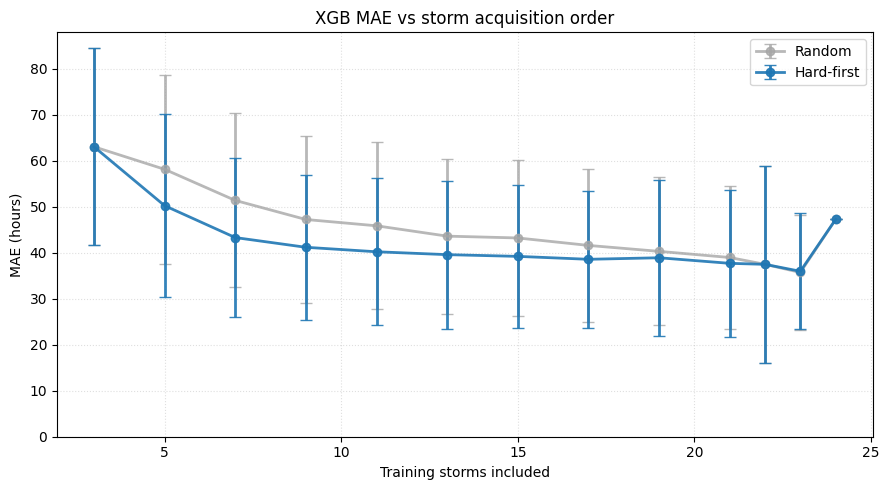

In [6]:
# --- Storm acquisition experiment: hard-first vs random ---
# Non-leaky version:
#   - outer storms are held out for final evaluation
#   - within each outer training split, storms are acquired from a current pool
#   - the pool is scored by a baseline model at each round to decide which storms to add next
#
# Toggle:
#   - use_log_t90 = True  -> model log1p(t90), then back-transform to hours
#   - use_log_t90 = False -> model t90 directly in hours

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

# -----------------------
# Config
# -----------------------
use_log_t90 = True
seed_n_storms = 3
add_n_storms = 2
n_outer_splits = 5
n_repeats_per_outer = 10
base_seed = 42

# Tuned full-CONUS XGB hyperparameters from CONUS_modelling
xgb_params = {
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
    "learning_rate": 0.3,
    "n_estimators": 100,
    "max_depth": 6,
    "min_child_weight": 1,
    "subsample": 1.0,
    "colsample_bytree": 0.7,
    "gamma": 0.5,
    "reg_alpha": 0.0,
    "reg_lambda": 8.0,
}

features_v4 = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    "storm_max_wind_near_conus_mps",
    "county_gdp_real_2017_dollars",
    "county_gdp_real_2017_per_capita",
]

# -----------------------
# Load data
# -----------------------
data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"
df = event_df.copy() if "event_df" in globals() else pd.read_parquet(data_path)

df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
df["storm"] = df["storm"].astype(str)

if "t90" not in df.columns and "t90_lastcross" in df.columns:
    df["t90"] = df["t90_lastcross"]

if "t90" not in df.columns:
    raise RuntimeError("Could not find t90 in the dataset.")

df = df.dropna(subset=["t90"]).copy()

print("Storm acquisition experiment summary")
print("------------------------------------")
print(f"County-event rows: {len(df)}")
print(f"Unique storms:     {df['storm'].nunique(dropna=True)}")
print(f"Unique counties:   {df['CountyFIPS'].nunique(dropna=True)}")
print(f"Log-transform t90: {use_log_t90}")

# -----------------------
# Helpers
# -----------------------
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features_v4)
])

def wrap_target(model):
    if use_log_t90:
        return TransformedTargetRegressor(
            regressor=model,
            func=np.log1p,
            inverse_func=np.expm1,
            check_inverse=False,
        )
    return model

def make_baseline_model():
    base = Pipeline([
        ("preprocess", preprocess),
        ("lr", LinearRegression()),
    ])
    return wrap_target(base)

def make_main_model():
    base = Pipeline([
        ("preprocess", preprocess),
        ("xgb", XGBRegressor(**xgb_params)),
    ])
    return wrap_target(base)

def clip_nonnegative(arr):
    return np.clip(np.asarray(arr, dtype=float), 0.0, None)

def fit_and_score(train_df, test_df, model_factory):
    X_train = train_df[features_v4].copy()
    y_train = train_df["t90"].astype(float).copy()
    X_test = test_df[features_v4].copy()
    y_test = test_df["t90"].astype(float).copy()

    model = model_factory()
    model.fit(X_train, y_train)
    preds = clip_nonnegative(model.predict(X_test))
    mae = mean_absolute_error(y_test, preds)
    return mae

def rank_current_pool_by_hardness(train_df, pool_df):
    """
    Score each storm in the current pool using a baseline model trained on the current training set.
    Hardest storms are those with the largest MAE.
    """
    if pool_df.empty:
        return []

    baseline = make_baseline_model()
    baseline.fit(train_df[features_v4], train_df["t90"].astype(float))

    storm_scores = []
    for storm in pool_df["storm"].dropna().unique():
        storm_df = pool_df[pool_df["storm"] == storm].copy()
        if storm_df.empty:
            continue
        preds = clip_nonnegative(baseline.predict(storm_df[features_v4]))
        mae = mean_absolute_error(storm_df["t90"].astype(float), preds)
        storm_scores.append((storm, mae))

    storm_scores.sort(key=lambda x: x[1], reverse=True)
    return [s for s, _ in storm_scores]

def run_sequence(train_df, test_df, seed_storms, strategy, rng):
    """
    Build a training sequence from a fixed seed set by adding storms in either:
      - hard-first order, or
      - random order
    """
    train_storms = list(train_df["storm"].dropna().unique())
    current = list(seed_storms)
    current = [s for s in current if s in train_storms]
    remaining = [s for s in train_storms if s not in current]

    rows = []

    def evaluate_current(current_storms):
        current_train_df = train_df[train_df["storm"].isin(current_storms)].copy()
        if current_train_df["storm"].nunique() < 2:
            return None

        mae = fit_and_score(current_train_df, test_df, make_main_model)
        return {
            "n_train_storms_used": len(current_storms),
            "n_train_rows_used": len(current_train_df),
            "mae": mae,
        }

    # Initial seed point
    init_eval = evaluate_current(current)
    if init_eval is not None:
        rows.append(init_eval)

    # Add storms until the training pool is exhausted
    while len(remaining) > 0:
        add_n = min(add_n_storms, len(remaining))

        if strategy == "hard-first":
            current_train_df = train_df[train_df["storm"].isin(current)].copy()
            pool_df = train_df[train_df["storm"].isin(remaining)].copy()
            ordered_pool = rank_current_pool_by_hardness(current_train_df, pool_df)
            chosen = ordered_pool[:add_n]
        elif strategy == "random":
            chosen = list(rng.choice(remaining, size=add_n, replace=False))
        else:
            raise ValueError("strategy must be 'hard-first' or 'random'")

        current.extend(chosen)
        remaining = [s for s in remaining if s not in chosen]

        step_eval = evaluate_current(current)
        if step_eval is not None:
            rows.append(step_eval)

    return rows

# -----------------------
# Outer evaluation
# -----------------------
storms = df["storm"].dropna().unique()
n_storms = len(storms)
if n_storms < 3:
    raise RuntimeError("Not enough storms for grouped outer evaluation.")

outer_splits = min(n_outer_splits, n_storms)
outer_cv = GroupKFold(n_splits=outer_splits)

curve_rows = []

for outer_fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(df, df["t90"], groups=df["storm"]),
    start=1
):
    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    train_storms = list(train_df["storm"].dropna().unique())
    if len(train_storms) < seed_n_storms + 1:
        continue

    for rep in range(1, n_repeats_per_outer + 1):
        seed_rng = np.random.default_rng(base_seed + 1000 * outer_fold + rep)
        seed_storms = list(seed_rng.choice(train_storms, size=seed_n_storms, replace=False))

        # Hard-first sequence
        hard_rng = np.random.default_rng(base_seed + 2000 * outer_fold + rep)
        hard_rows = run_sequence(train_df, test_df, seed_storms, "hard-first", hard_rng)
        for r in hard_rows:
            r["strategy"] = "Hard-first"
            r["outer_fold"] = outer_fold
            r["repeat"] = rep
            curve_rows.append(r)

        # Random sequence
        rand_rng = np.random.default_rng(base_seed + 3000 * outer_fold + rep)
        rand_rows = run_sequence(train_df, test_df, seed_storms, "random", rand_rng)
        for r in rand_rows:
            r["strategy"] = "Random"
            r["outer_fold"] = outer_fold
            r["repeat"] = rep
            curve_rows.append(r)

curve_df = pd.DataFrame(curve_rows)

if curve_df.empty:
    raise RuntimeError("No curve results were produced.")

summary = (
    curve_df.groupby(["strategy", "n_train_storms_used"], as_index=False)
    .agg(
        mae_mean=("mae", "mean"),
        mae_sd=("mae", "std"),
        n_train_rows_used_mean=("n_train_rows_used", "mean"),
    )
    .sort_values(["strategy", "n_train_storms_used"])
    .reset_index(drop=True)
)

print("\nAdaptive sampling summary")
print("-------------------------")
print(summary.to_string(index=False))

print("\nInterpretation note")
print("-------------------")
print(
    "Hard-first ranks the current acquisition pool using a baseline model trained only on the current training set.\n"
    "The outer test storms are never used to decide the order.\n"
    "MAE is reported on the original hours scale after any optional log transform is back-transformed."
)

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(9, 5))

for strategy, color in [("Random", "0.65"), ("Hard-first", "tab:blue")]:
    sub = summary[summary["strategy"] == strategy].copy()
    x = sub["n_train_storms_used"]

    ax.errorbar(
        x,
        sub["mae_mean"],
        yerr=sub["mae_sd"],
        marker="o",
        linewidth=2,
        capsize=4,
        label=strategy,
        color=color,
        alpha=0.9 if strategy == "Hard-first" else 0.8,
    )

ax.set_xlabel("Training storms included")
ax.set_ylabel("MAE (hours)")
ax.set_title("XGB MAE vs storm acquisition order")
ax.set_ylim(bottom=0)
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()